<a href="https://colab.research.google.com/github/shanusushmita/CS4973-Applied-Multilingual-Systems/blob/main/Embedding_Visualization_with_t_SNE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Set a style for better aesthetics
sns.set_style("whitegrid")

# --- 1. Simulate Linguistically Grouped Embeddings ---
num_per_group = 20
embedding_dim = 50
np.random.seed(42)

embeddings = []
labels_lang_pos = []

# Group 1: English Nouns (EN-N) - Cluster 1 Center (e.g., [2, 2, ...])
for i in range(num_per_group):
    embeddings.append(np.random.normal(loc=2.0, scale=0.3, size=embedding_dim))
    labels_lang_pos.append('EN_NOUN')

# Group 2: English Verbs (EN-V) - Cluster 2 Center (e.g., [-2, 2, ...])
for i in range(num_per_group):
    embeddings.append(np.random.normal(loc=-2.0, scale=0.3, size=embedding_dim))
    labels_lang_pos.append('EN_VERB')

# Group 3: Spanish Nouns (ES-N) - Cluster 3 Center (should be near EN-N, but distinct)
for i in range(num_per_group):
    embeddings.append(np.random.normal(loc=2.5, scale=0.3, size=embedding_dim))
    labels_lang_pos.append('ES_NOUN')

# Group 4: Spanish Verbs (ES-V) - Cluster 4 Center (should be near EN-V, but distinct)
for i in range(num_per_group):
    embeddings.append(np.random.normal(loc=-2.5, scale=0.3, size=embedding_dim))
    labels_lang_pos.append('ES_VERB')

# Group 5: Code-Switched Tokens (CS) - Cluster 5 Center (ambiguous, near center [0, 0, ...])
for i in range(num_per_group):
    embeddings.append(np.random.normal(loc=0.0, scale=0.5, size=embedding_dim))
    labels_lang_pos.append('CS_TOKEN')

embeddings = np.array(embeddings)

In [2]:
# --- 2. Scale the Embeddings ---
scaler = StandardScaler()
scaled_embeddings = scaler.fit_transform(embeddings)

# --- 3. Apply t-SNE ---
# Use standard parameters. Perplexity can be adjusted for different data sizes.
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, learning_rate=200, random_state=42)
tsne_results = tsne.fit_transform(scaled_embeddings)

# Prepare DataFrame for plotting, using the combined language/POS labels
df_tsne = pd.DataFrame({
    'tsne_x': tsne_results[:, 0],
    'tsne_y': tsne_results[:, 1],
    'linguistic_tag': labels_lang_pos
})

print("t-SNE results head:\n", df_tsne.head())

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE results head:
      tsne_x    tsne_y linguistic_tag
0  4.764606  3.952330        EN_NOUN
1  4.906740  3.994421        EN_NOUN
2  4.993959  4.197200        EN_NOUN
3  5.254961  3.998624        EN_NOUN
4  4.851215  4.275255        EN_NOUN


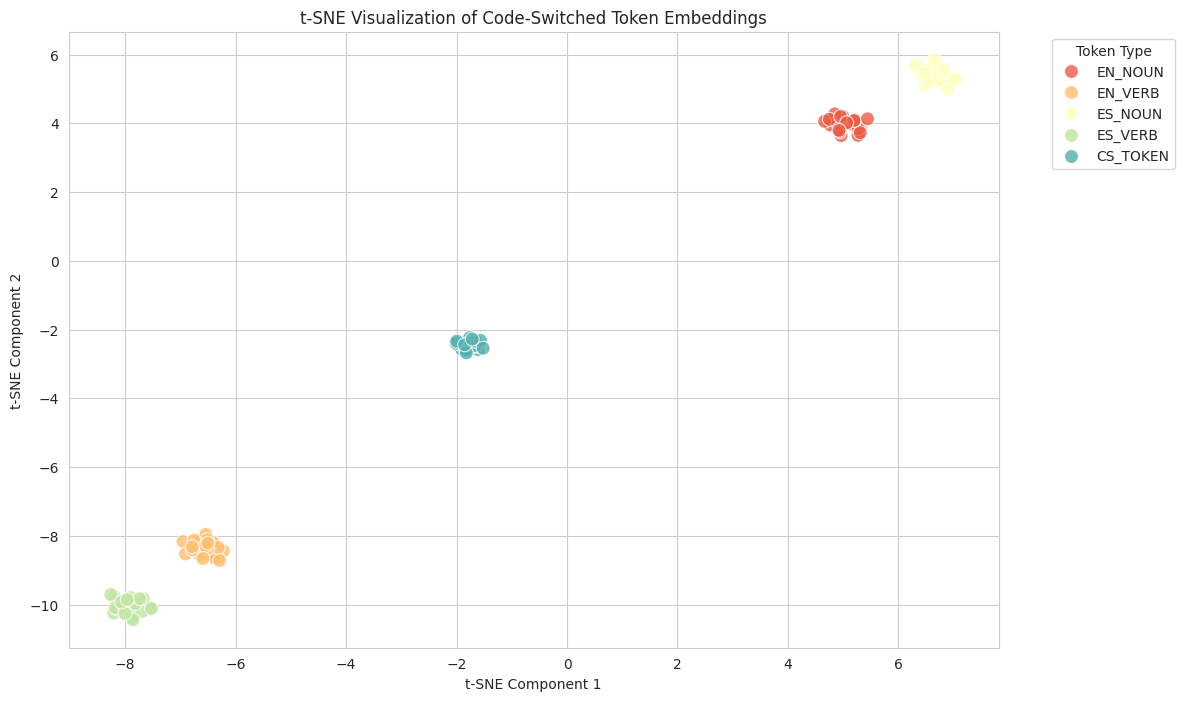

In [3]:
# --- 4. Plotting - Colored by Specific Linguistic Tag ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='tsne_x', y='tsne_y',
    hue='linguistic_tag', # Color points based on the combined label (EN_NOUN, ES_NOUN, CS_TOKEN, etc.)
    palette='Spectral',   # Use a distinctive color palette
    data=df_tsne,
    legend='full',
    alpha=0.8,
    s=100
)

plt.title('t-SNE Visualization of Code-Switched Token Embeddings')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.legend(title='Token Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# --- Interpreting the Expected Output ---
# 1. Clustering by Language (EN vs. ES): EN_NOUN and EN_VERB should be near each other.
# 2. Clustering by POS (NOUN vs. VERB): EN_NOUN and ES_NOUN should be closer than EN_NOUN and EN_VERB.
# 3. Code-Switched Tokens (CS_TOKEN): These should be in the center, potentially overlapping the boundaries of the EN and ES clusters, reflecting their linguistic ambiguity or neutrality in the model's eyes.